<a href="https://colab.research.google.com/github/naufal11705/PCVK_Genap_2021/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

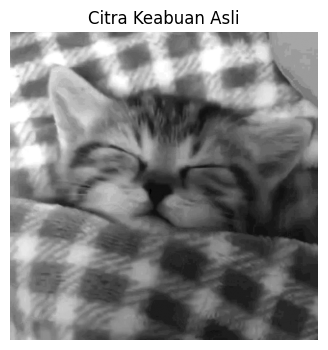

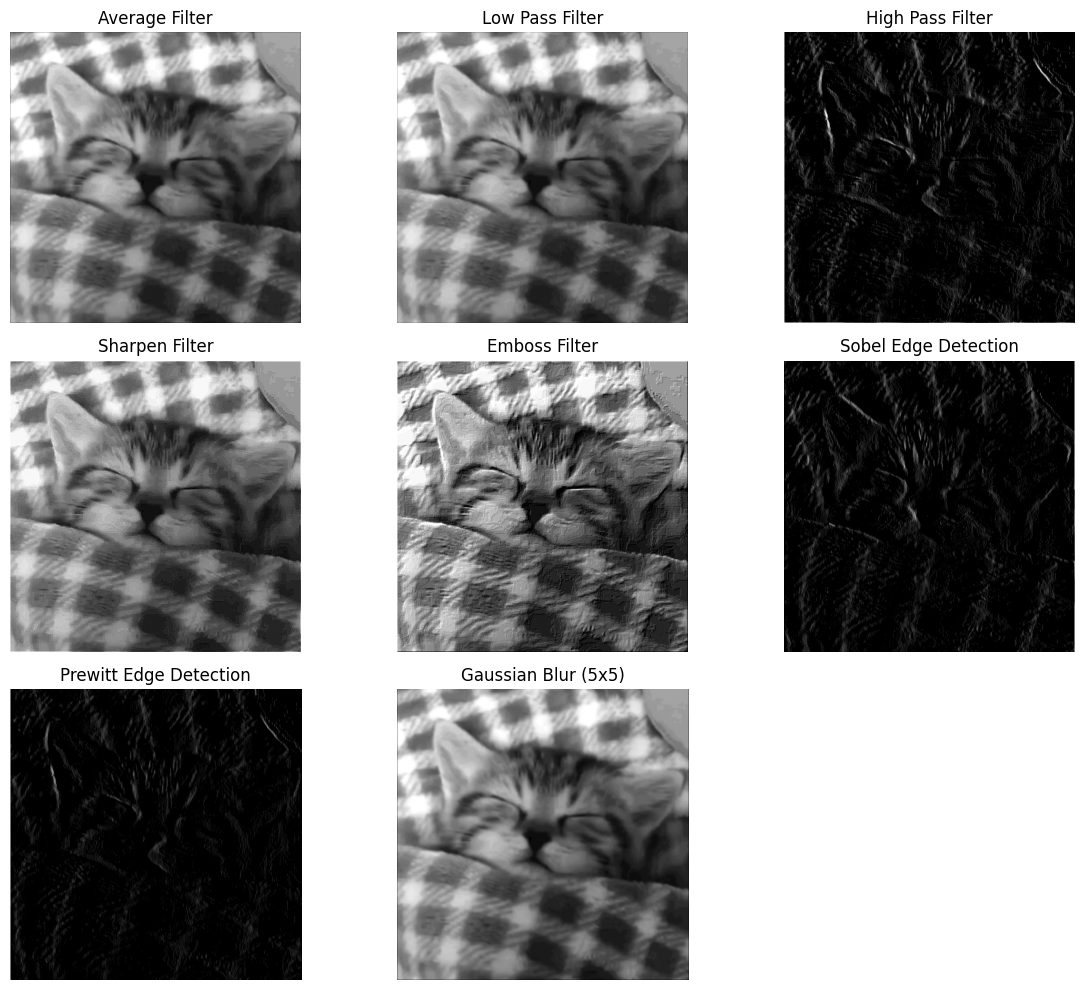

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math
from urllib.request import urlopen

# --- 1. Load gambar dari URL ---
url = 'https://media.tenor.com/tIPDs-HGMHkAAAAe/cat-catto.png'
resp = urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img = cv.imdecode(image, cv.IMREAD_COLOR)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(4,4))
plt.imshow(gray, cmap='gray')
plt.title('Citra Keabuan Asli')
plt.axis('off')
plt.show()

# --- 2. Fungsi konvolusi manual ---
def konvolusi(image, kernel):
    m, n = kernel.shape
    y, x = image.shape
    pad = m // 2
    img_padded = np.pad(image, pad, mode='constant', constant_values=0)
    output = np.zeros_like(image, dtype=float)

    for i in range(y):
        for j in range(x):
            region = img_padded[i:i+m, j:j+n]
            output[i, j] = np.sum(region * kernel)
    return np.clip(output, 0, 255).astype(np.uint8)

# --- 3. Definisi kernel berbagai filter ---
average_kernel = np.ones((3,3), np.float32) / 9
low_pass_kernel = np.array([[1,1,1],[1,4,1],[1,1,1]]) / 12
high_pass_kernel = np.array([[-1,0,1],[-1,0,3],[-3,0,1]])
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
emboss_kernel = np.array([[-2,-1,0],[-1,1,1],[0,1,2]])
sobel_kernel = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
prewitt_kernel = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])

# Gaussian 5x5
kernel_size = 5
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss5 = gaussian_kernel @ gaussian_kernel.T

# --- 4. Aplikasikan semua filter ---
filters = {
    "Average Filter": average_kernel,
    "Low Pass Filter": low_pass_kernel,
    "High Pass Filter": high_pass_kernel,
    "Sharpen Filter": sharpen_kernel,
    "Emboss Filter": emboss_kernel,
    "Sobel Edge Detection": sobel_kernel,
    "Prewitt Edge Detection": prewitt_kernel,
    "Gaussian Blur (5x5)": gauss5
}

plt.figure(figsize=(12,10))
for idx, (name, kernel) in enumerate(filters.items(), 1):
    result = konvolusi(gray, kernel)
    plt.subplot(3,3,idx)
    plt.imshow(result, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()
